In [ ]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from inference_utils import process_large_image

In [2]:
model_weight_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/Preprocessing/runs/segment/train8/weights/best.pt'
# image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/tiles/images/5_14.png'
image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/global_images/9.jpg'
# image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/global_images/4.webp'

conf_thresh = 0.7

In [3]:
model = YOLO(model_weight_path)
model.info()

YOLO11l-seg summary: 379 layers, 27,617,459 parameters, 0 gradients, 132.6 GFLOPs


(379, 27617459, 0, 132.5988352)

In [4]:
model.info()

YOLO11l-seg summary: 379 layers, 27,617,459 parameters, 0 gradients, 132.6 GFLOPs


(379, 27617459, 0, 132.5988352)

In [ ]:
mask_result = process_large_image(image_path, model_weight_path, tile_size=640, overlap=50, conf_thresh=conf_thresh)

In [7]:
# cv2.imwrite('combined_mask_overlap.png', mask_result)
output_filepath = Path(image_path).parent / Path(str(Path(image_path).stem + '_mask_inv_estimated.jpg'))
print(output_filepath)
cv2.imwrite(str(output_filepath), mask_result)

/home/tinmar/Desktop/Projects/Datasets/Puzzle/global_images/9_mask_inv_estimated.jpg


True

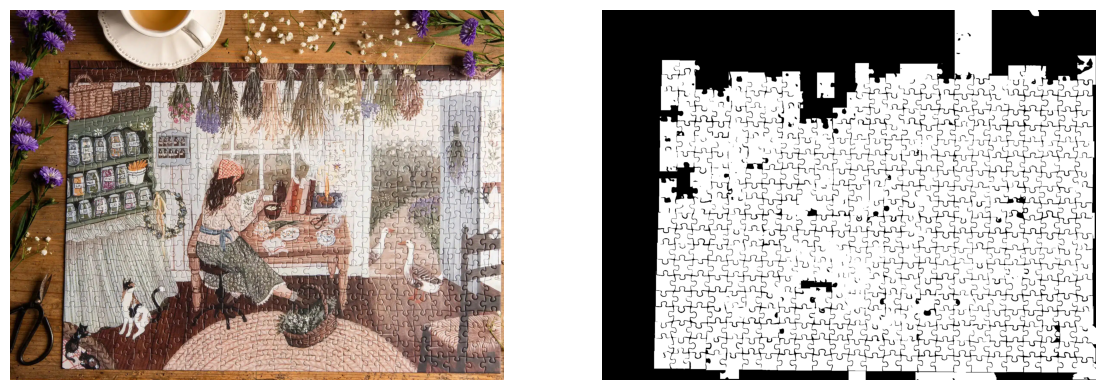

In [8]:
plt.figure(figsize=(14, 10))
plt.subplot(121)
plt.imshow(cv2.imread(image_path)[:,:,::-1])  # Conversion BGR to RGB 
plt.axis('off')
plt.subplot(122)
plt.imshow(mask_result, cmap='gray')
plt.axis('off')
plt.show()